# 查看 `MAGNDATA` 数据

In [1]:
import numpy as np
import pandas as pd

In [4]:
magndata_csv = "./data/magndata.csv"
df = pd.read_csv(magndata_csv)

In [7]:
df.head()

,id,tc,pos,cell,charges,elements,count,tc_scale,tc_log
0,0.1000_Fe4O5,150,"[[-3.0310799999999997e-16, 4.9519764319999995,...","[[2.8906, 0.0, 2e-16], [-6e-16, 9.8024, 6e-16]...","[26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 2...","['Fe', 'Fe', 'Fe', 'Fe', 'Fe', 'Fe', 'Fe', 'Fe...",36,0.301914,5.017280
1,0.1001_PbMn2Ni6Te3O18,86,"[[4.676647957779778e-16, 5.354404131491508, 0....","[[9.2741, 0.0, 6e-16], [-4.6370499999999995, 8...","[25, 25, 25, 25, 28, 28, 28, 28, 28, 28, 28, 2...","['Mn', 'Mn', 'Mn', 'Mn', 'Ni', 'Ni', 'Ni', 'Ni...",60,-0.112718,4.465908
2,0.1004_CsO2,10,"[[3.31018903, 0.9419659199999999, 5.50395], [7...","[[8.7271, 0.0, 5e-16], [-3e-16, 4.3976, 3e-16]...","[55, 55, 55, 55, 8, 8, 8, 8, 8, 8, 8, 8]","['Cs', 'Cs', 'Cs', 'Cs', 'O', 'O', 'O', 'O', '...",12,-0.605094,2.397895
3,0.1008_Sr2ErRuO6,50,"[[0.04542466513905109, 0.1757898, 2.0320485009...","[[5.749957612538115, 0.0, -0.0220783607856446]...","[38, 38, 38, 38, 68, 68, 44, 44, 8, 8, 8, 8, 8...","['Sr', 'Sr', 'Sr', 'Sr', 'Er', 'Er', 'Ru', 'Ru...",20,-0.345949,3.931826
4,0.1009_CaBaFe4O7,274,"[[0.006313499999999532, 7.37718408, 5.38494891...","[[6.3135, 0.0, 4e-16], [-7e-16, 11.0173, 7e-16...","[56, 56, 56, 56, 20, 20, 20, 20, 26, 26, 26, 2...","['Ba', 'Ba', 'Ba', 'Ba', 'Ca', 'Ca', 'Ca', 'Ca...",52,1.105263,5.616771


In [8]:
mp_20_df = pd.read_csv("../data/mp_20/train.csv")

In [9]:
mp_20_df.head()

,Unnamed: 0,material_id,formation_energy_per_atom,band_gap,pretty_formula,e_above_hull,elements,cif,spacegroup.number
0,37228,mp-1221227,-1.637460,0.2133,Na3MnCoNiO6,0.043001,"['Co', 'Mn', 'Na', 'Ni', 'O']",# generated using pymatgen\ndata_Na3MnCoNiO6\n...,8
1,19480,mp-974729,-0.314759,0.0000,Nd(Al2Cu)4,0.000000,"['Al', 'Cu', 'Nd']",# generated using pymatgen\ndata_Nd(Al2Cu)4\n_...,139
2,29624,mp-1185360,-0.193761,0.0000,LiMnIr2,0.018075,"['Ir', 'Li', 'Mn']",# generated using pymatgen\ndata_LiMnIr2\n_sym...,225
3,38633,mp-1188861,-0.584694,3.8556,LiCSN,0.048847,"['C', 'Li', 'N', 'S']",# generated using pymatgen\ndata_LiCSN\n_symme...,62
4,10889,mp-677272,-2.474759,0.4707,La2EuS4,0.000000,"['Eu', 'La', 'S']",# generated using pymatgen\ndata_La2EuS4\n_sym...,122


# 按照 MP 的数据格式重构 Tc 的数据

In [4]:
import pandas as pd
import ast
import warnings
from collections import defaultdict

# 忽略一些 Pymatgen 可能会产生的非关键性警告
warnings.filterwarnings("ignore")

from pymatgen.core import Structure, Lattice
from pymatgen.io.cif import CifWriter
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.structure_matcher import StructureMatcher

# 1. 读取原始数据集
file_path = "../pre_processing/data/magndata.csv"
print(f"正在读取数据文件: {file_path}")
df = pd.read_csv(file_path)

# 保存原始数据集的所有索引，用于最后比对丢失了哪些行
original_indices = set(df.index)
print(f"原始数据集总共有 {len(original_indices)} 行数据。")

# 2. 预检查：是否存在两行完全一样的数据
initial_len = len(df)
# 由于后续列表列不能直接去重，我们在转化字符串前做基于字符串的全局去重
df = df.drop_duplicates()
removed_exact_duplicates = initial_len - len(df)
if removed_exact_duplicates > 0:
    print(f"【注意】发现了 {removed_exact_duplicates} 行完全重复的数据，已优先剔除。")
else:
    print("未发现完全一模一样的重复行。")

# 3. 将字符串还原为Python列表
list_columns = ['pos', 'cell', 'elements']
for col in list_columns:
    df[col] = df[col].apply(ast.literal_eval)

print("正在构建晶体结构对象并提取特征...")

# 用于暂存成功解析的结构及其关联信息
parsed_data = []

for index, row in df.iterrows():
    try:
        # A. 构建晶体结构对象
        lattice = Lattice(row['cell'])
        struct = Structure(
            lattice=lattice,
            species=row['elements'],
            coords=row['pos'],
            coords_are_cartesian=True
        )

        # B. 获取规范化的化学式
        pretty_formula = struct.composition.reduced_formula

        # C. 获取唯一元素列表
        unique_elements = [str(el) for el in struct.composition.elements]
        unique_elements.sort()
        elements_str = str(unique_elements)

        # D. 生成 CIF 字符串数据
        cif_data = str(CifWriter(struct))

        # E. 获取空间群数字编号
        sga = SpacegroupAnalyzer(struct)
        spacegroup_number = sga.get_space_group_number()

        # F. 整合为新格式的数据行
        new_row = {
            'material_id': row['id'],
            'tc': row['tc'],
            'tc_scale': row['tc_scale'],
            'tc_log': row['tc_log'],
            'pretty_formula': pretty_formula,
            'elements': elements_str,
            'charges': row['charges'],          # 保留原本的 charges 列
            'cif': cif_data,
            'spacegroup.number': spacegroup_number,
            'natoms': row['count']
        }

        # 将结构对象、新数据行和原始索引打包暂存
        parsed_data.append({
            'original_index': index,
            'material_id': row['id'],
            'tc': row['tc'],
            'struct': struct,
            'new_row': new_row
        })

    except Exception as e:
        print(f"【报错】处理原始第 {index} 行数据（ID: {row['id']}）时出错: {e}")

# 4. 等价结构匹配 & Tc值对比过滤
print("\n正在进行等价结构匹配及 Tc 值校验...")
matcher = StructureMatcher()

# 按化学式分组以加速匹配过程，只有化学式相同的才可能是等价结构
formula_groups = defaultdict(list)
for item in parsed_data:
    formula = item['new_row']['pretty_formula']
    formula_groups[formula].append(item)

all_dataset_rows = []       # 保存所有解析成功的结构（包含等价结构）
final_dataset_rows = []     # 保存去重后的结构
final_saved_indices = set() # 记录去重数据集中保留的原始行索引
report_lines = []           # 用于写入 txt 的报告内容

for formula, items in formula_groups.items():
    if len(items) == 1:
        # 该化学式下只有一个结构，绝对唯一
        item = items[0]
        all_dataset_rows.append(item['new_row'])
        final_dataset_rows.append(item['new_row'])
        final_saved_indices.add(item['original_index'])
        continue

    # 在相同化学式的组内进行精确结构匹配
    equivalent_groups = []
    for item in items:
        matched = False
        for group in equivalent_groups:
            # 与组内的第一个代表性结构进行匹配
            if matcher.fit(item['struct'], group[0]['struct']):
                group.append(item)
                matched = True
                break
        if not matched:
            equivalent_groups.append([item])

    # 处理匹配结果
    for group in equivalent_groups:
        # 1. 将该组内所有结构都保存到全量数据集中
        for item in group:
            all_dataset_rows.append(item['new_row'])

        # 2. 判断是否包含重复等价结构，并应用 Tc 过滤规则
        is_equiv_group = len(group) > 1
        seen_tcs = set() # 用于记录当前等价组中已经出现过的 Tc 值

        if is_equiv_group:
            report_lines.append(f"--- 等价结构组 (化学式: {group[0]['new_row']['pretty_formula']}) ---")

        for item in group:
            tc_val = item['tc']

            # 如果 Tc 值在这个等价结构组中第一次出现，则保留
            if tc_val not in seen_tcs:
                final_dataset_rows.append(item['new_row'])
                final_saved_indices.add(item['original_index'])
                seen_tcs.add(tc_val) # 记录该 Tc 值

                if is_equiv_group:
                    report_lines.append(f"原始行索引: {item['original_index']:<5} | ID: {item['material_id']:<15} | Tc: {item['tc']:<8} | 状态: 保留 (首个或不同Tc)")
            else:
                # 结构等价，且 Tc 值也跟前面的一模一样，剔除
                if is_equiv_group:
                    report_lines.append(f"原始行索引: {item['original_index']:<5} | ID: {item['material_id']:<15} | Tc: {item['tc']:<8} | 状态: 剔除 (等价且Tc相同)")

        if is_equiv_group:
            report_lines.append("") # 打印一个空行作为分隔

# 5. 输出等价结构记录报告
report_path = '../pre_processing/data/equivalent_structures_report.txt'
if report_lines:
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("等价结构检查及处理报告\n")
        f.write("="*50 + "\n\n")
        f.write("\n".join(report_lines))
    print(f"\n【提示】发现等价结构，详细比对和剔除记录已保存至: {report_path}")
else:
    print("\n完美：未发现任何等价重复的结构。")
    # 生成一个空报告说明情况
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("完美：未发现任何等价重复的结构。\n")

# 6. 检查丢失/未转化保存的数据行 (针对去重后的数据集)
dropped_indices = original_indices - final_saved_indices
print("\n" + "#"*40)
print("             数据集转化总结")
print("#"*40)
print(f"1. 原始数据集总行数: {len(original_indices)}")
print(f"2. 成功解析的所有结构数 (含等价): {len(all_dataset_rows)}")
print(f"3. 剔除等价且Tc相同后，最终去重保存数: {len(final_saved_indices)}")
print(f"*. 共有 {len(dropped_indices)} 行数据没有进入最终去重的数据集。")

# 7. 创建 DataFrame 并导出两个文件
columns_order = [
    'material_id', 'tc', 'tc_scale', 'tc_log',
    'pretty_formula', 'natoms', 'elements', 'charges', 'cif', 'spacegroup.number'
]

# A. 保存包含所有解析结构的完整数据集
all_df = pd.DataFrame(all_dataset_rows)[columns_order]
# 在最前面插入 seq_id 序号列，从 1 开始
all_df.insert(0, 'seq_id', range(1, len(all_df) + 1))
output_path_all = '../pre_processing/data/magndata_tc_all.csv'
all_df.to_csv(output_path_all, index=False)
print(f"\n✅ 完整结构数据集 (包含等价结构) 已保存至: {output_path_all}")

# B. 保存去重后的数据集
dedup_df = pd.DataFrame(final_dataset_rows)[columns_order]
# 在最前面插入 seq_id 序号列，从 1 开始
dedup_df.insert(0, 'seq_id', range(1, len(dedup_df) + 1))
output_path_dedup = '../pre_processing/data/magndata_tc.csv'
dedup_df.to_csv(output_path_dedup, index=False)
print(f"✅ 去重过滤数据集 (剔除等价且Tc相同的结构) 已保存至: {output_path_dedup}")

正在读取数据文件: ../pre_processing/data/magndata.csv
原始数据集总共有 1468 行数据。
未发现完全一模一样的重复行。
正在构建晶体结构对象并提取特征...
【报错】处理原始第 189 行数据（ID: 0.266_Na2BaCo(VO4)2）时出错: too close distance between atoms
【报错】处理原始第 251 行数据（ID: 0.338_Co2Mo3O8）时出错: too close distance between atoms
【报错】处理原始第 1062 行数据（ID: 1.441_NaFe3(SO4)2(OH)6）时出错: too close distance between atoms
【报错】处理原始第 1341 行数据（ID: 1.822_Sr2MnSi2O7）时出错: too close distance between atoms

正在进行等价结构匹配及 Tc 值校验...

【提示】发现等价结构，详细比对和剔除记录已保存至: ../pre_processing/data/equivalent_structures_report.txt

########################################
             数据集转化总结
########################################
1. 原始数据集总行数: 1468
2. 成功解析的所有结构数 (含等价): 1464
3. 剔除等价且Tc相同后，最终去重保存数: 1297
*. 共有 171 行数据没有进入最终去重的数据集。

✅ 完整结构数据集 (包含等价结构) 已保存至: ../pre_processing/data/magndata_tc_all.csv
✅ 去重过滤数据集 (剔除等价且Tc相同的结构) 已保存至: ../pre_processing/data/magndata_tc.csv


正在读取数据: ../pre_processing/data/magndata_tc.csv ...
正在基于 Pymatgen 提取特征，这可能需要一小段时间...
正在按 8:1:1 划分训练集、验证集和测试集...
训练集大小: 1037 个样本
验证集大小: 130 个样本
测试集大小: 130 个样本
正在训练随机森林模型 (RandomForestRegressor)...

--- 模型评估结果 ---
[训练集] MAE: 31.13 K, RMSE: 54.01 K, R²: 0.8677
[验证集] MAE: 68.94 K, RMSE: 102.74 K, R²: 0.4242
[测试集] MAE: 83.82 K, RMSE: 149.15 K, R²: 0.2770

--- Top 5 重要特征 ---
1. volume: 0.2042
2. mean_X: 0.1529
3. max_Z: 0.1284
4. density: 0.0979
5. volume_per_atom: 0.0947

测试集预测散点图已保存为 'tc_prediction_scatter.png'


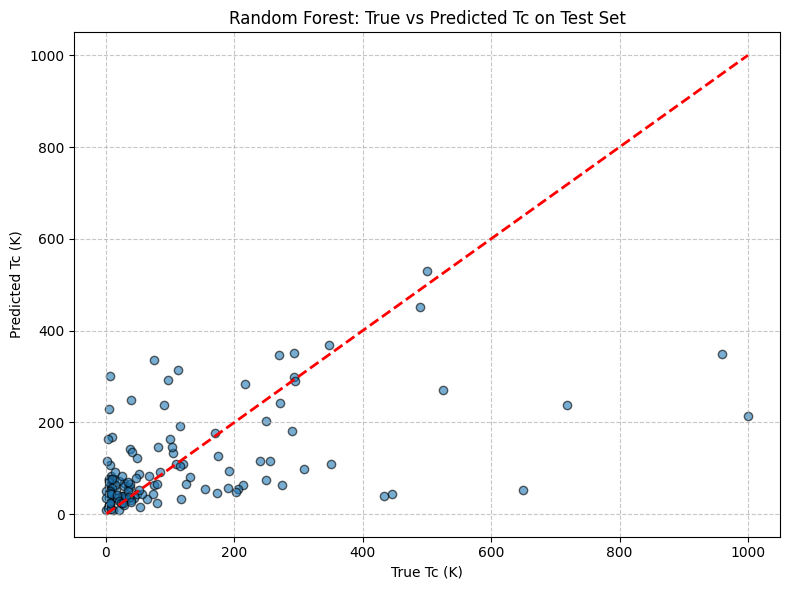

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pymatgen.core import Composition, Structure
import matplotlib.pyplot as plt
import warnings

# 忽略不必要的警告
warnings.filterwarnings('ignore')

def extract_features(row):
    """
    基于化学式 (pretty_formula) 和 晶体结构 (cif) 提取特征
    """
    features = {}

    # 1. 基础特征 (来自CSV原始列)
    features['natoms'] = row.get('natoms', 0)
    features['spacegroup'] = row.get('spacegroup.number', 0)

    # 2. 化学成分特征 (基于 pymatgen)
    try:
        comp = Composition(row['pretty_formula'])
        features['nelements'] = len(comp.elements)

        # 提取原子序数(Z)和原子质量
        Z_list = [el.Z for el in comp.elements]
        mass_list = [el.atomic_mass for el in comp.elements]
        fractions = [comp.get_atomic_fraction(el) for el in comp.elements]

        features['mean_Z'] = sum(z * f for z, f in zip(Z_list, fractions))
        features['max_Z'] = max(Z_list)
        features['mean_mass'] = sum(m * f for m, f in zip(mass_list, fractions))

        # 提取电负性 (排除没有Pauling电负性的元素)
        X_list = [el.X for el in comp.elements if el.X is not None]
        if len(X_list) > 0:
            features['mean_X'] = np.mean(X_list)
            features['max_X'] = max(X_list)
        else:
            features['mean_X'] = 0
            features['max_X'] = 0

    except Exception as e:
        # 如果化学式解析失败，填充默认值
        features['nelements'] = 0
        features['mean_Z'] = 0
        features['max_Z'] = 0
        features['mean_mass'] = 0
        features['mean_X'] = 0
        features['max_X'] = 0

    # 3. 晶体结构特征 (基于 CIF 文件)
    try:
        # 从 CIF 字符串中解析晶体结构
        structure = Structure.from_str(row['cif'], fmt="cif")
        features['density'] = structure.density
        features['volume'] = structure.volume
        features['volume_per_atom'] = structure.volume / structure.num_sites
    except Exception as e:
        features['density'] = 0
        features['volume'] = 0
        features['volume_per_atom'] = 0

    return pd.Series(features)

def main():
    # 1. 读取数据
    data_path = "../pre_processing/data/magndata_tc.csv"
    print(f"正在读取数据: {data_path} ...")
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        print("未找到指定路径的CSV文件，请检查文件路径！")
        return

    # 去除Tc为空的行
    df = df.dropna(subset=['tc'])

    # 2. 特征工程 (Featurization)
    print("正在基于 Pymatgen 提取特征，这可能需要一小段时间...")
    feature_df = df.apply(extract_features, axis=1)

    # 目标变量：这里我们预测原始的 tc 值，如果你想预测对数可以改为 df['tc_log']
    X = feature_df.values
    y = df['tc'].values

    # 3. 数据划分 (8 : 1 : 1)
    print("正在按 8:1:1 划分训练集、验证集和测试集...")
    # 先分出 80% 训练集, 和 20% 的临时集
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
    # 将 20% 的临时集平分为 10% 验证集 和 10% 测试集
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    print(f"训练集大小: {len(X_train)} 个样本")
    print(f"验证集大小: {len(X_val)} 个样本")
    print(f"测试集大小: {len(X_test)} 个样本")

    # 4. 建立与训练随机森林模型
    print("正在训练随机森林模型 (RandomForestRegressor)...")
    rf_model = RandomForestRegressor(n_estimators=100,
                                     max_depth=None,
                                     random_state=42,
                                     n_jobs=-1) # 使用所有CPU核心加速
    rf_model.fit(X_train, y_train)

    # 5. 预测与评估
    print("\n--- 模型评估结果 ---")

    def evaluate(model, X_data, y_true, dataset_name):
        y_pred = model.predict(X_data)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        print(f"[{dataset_name}] MAE: {mae:.2f} K, RMSE: {rmse:.2f} K, R²: {r2:.4f}")
        return y_pred

    evaluate(rf_model, X_train, y_train, "训练集")
    evaluate(rf_model, X_val, y_val, "验证集")
    y_test_pred = evaluate(rf_model, X_test, y_test, "测试集")

    # 6. 特征重要性分析
    feature_names = feature_df.columns
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    print("\n--- Top 5 重要特征 ---")
    for i in range(min(5, len(feature_names))):
        print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

    # 7. 可视化预测结果 (真实值 vs 预测值)
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k')

    # 画一条对角线，表示完美预测
    min_val = min(min(y_test), min(y_test_pred))
    max_val = max(max(y_test), max(y_test_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    plt.xlabel('True Tc (K)')
    plt.ylabel('Predicted Tc (K)')
    plt.title('Random Forest: True vs Predicted Tc on Test Set')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig('tc_prediction_scatter.png', dpi=300)
    print("\n测试集预测散点图已保存为 'tc_prediction_scatter.png'")

if __name__ == "__main__":
    main()